# BIO vs. BIOES label encoding for NER

#### Polina Kuzminykh, DS-02

## Background

Named-entity recognition (NER) is a sequence-labeling task that identifies spans of text belonging to predefined entity types (e.g. person, location, organization).

Two widely used annotation schemes are BIO and BIOES:
- BIO (Begin, Inside, Outside): uses three tags per entity type. B- marks the beginning of an entity, I- marks subsequent tokens inside the entity, and O marks tokens outside any entity.
- BIOES (Begin, Inside, Outside, End, Single): extends BIO with two additional tags per entity type: E- explicitly marks the last token of a multi-token entity, and S- marks a single-token entity (a word that is an entity by itself).

The additional explicit boundary markers in BIOES are intended to provide the model with more precise information about where entities begin and end, potentially improving boundary detection and reducing illegal transitions.

Prior work [[1]](https://aclanthology.org/W09-1119.pdf) shows that BIOES/BILOU tagging can outperform BIO on standard NER benchmarks.

However, more labels can also complicate learning. The tags B- and S- both signal the start of an entity, but only B- may continue into an I- tag, whereas S- always stands alone. This extra complexity can confuse models, as observed in [[2]](https://www.sciencedirect.com/science/article/pii/S1110866520301596): the researches report that on an Arabic medical dataset, the more detailed BIES tagging scheme significantly underperformed the much simpler IO scheme.

Overall, the impact of tag encoding may depend on data and model.

## Experimental setup

### Dataset

**[CoNLL-2003 English NER dataset](https://www.kaggle.com/datasets/alaakhaled/conll003-englishversion)** is a standard benchmark with four entity types (PER, LOC, ORG, MISC). It is widely used for NER evaluations. The data is already tokenized and annotated in IOB (BIO) format.

#### Dataset conversion strategy

Convert the original BIO-tagged data to BIOES by applying deterministic rules that map BI-token sequences to B, I, E, S tags based on entity span analysis. For multi-token entities (B I ... I), convert the final I to E. For single-token entities, convert B to S. O remains O.

### Model

Most modern NER systems use rich context models (e.g. bidirectional LSTM + CRF) to capture sequential dependencies. In my study I will use a **linear-chain CRF-based model** to isolate the effect of tag encoding. The goal is to compare how BIO vs. BIOES labeling affects model quality and decoding stability (invalid transitions, convergence) under controlled conditions.

### Evaluation strategy

Key measures are:
- span-level F1 (exact-match entity F1)
- invalid transition rate (fraction of predicted tag transitions that violate the scheme)
- convergence speed (training epochs to stable performance)
- performance on short vs. long entities (one-token vs. multi-token entities)

### Experimental design

- Training with BIO: train a model using BIO tagging. Evaluate on test set with key metrics.
- Training with BIOES: likewise for BIOES tagging.
- Constrained decoding (BIO): on the BIO model’s outputs, apply decoding constraints to disallow invalid tag sequences. Recompute metrics.
- Constrained decoding (BIOES): likewise for BIOES model’s outputs.

### Initial hypothesis

I assume that BIOES may give slightly better boundary precision (especially on single-token entities) due to explicit “S-” tags, but may also introduce more invalid predictions without constraints. Constrained decoding should reduce illegal transitions and may boost precision by correcting certain errors. Convergence might be similar for both schemes, though the richer label set could slow BIOES learning.

## Experiments

### Prepare train and test datasets for BIO and BIOES

In [12]:
import sklearn_crfsuite
import random

random.seed(0)

def load_conll_as_entity_types(path):
    """
    Load CoNLL-formatted NER data.

    Returns:
        list of sentences, where each sentence is a list of (word, entity_type)
        and entity_type is plain type (e.g., PER/LOC/ORG/MISC) or O.
    """
    sentences = []
    sent = []

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()

            # Sentence boundary
            if not line:
                if sent:
                    sentences.append(sent)
                    sent = []
                continue

            parts = line.split()
            token = parts[0]

            # Skip document marker lines
            if token == "-DOCSTART-":
                continue

            # CoNLL-2003: token pos chunk ner_tag
            ner_tag = parts[-1]

            if ner_tag == "O":
                ent_type = "O"
            else:
                # Convert BIO tag (B-ORG/I-ORG) -> plain entity type (ORG)
                ent_type = ner_tag.split("-", 1)[1]

            sent.append((token, ent_type))

    if sent:
        sentences.append(sent)

    return sentences

train = load_conll_as_entity_types("train.txt")
test = load_conll_as_entity_types("test.txt")

print(f"Loaded train sentences: {len(train)}")
print(f"Loaded test sentences: {len(test)}")

Loaded train sentences: 14041
Loaded test sentences: 3453


In [13]:
def to_BIO(entities):
    """Convert to BIO tagging scheme."""
    bio_tags = []
    prev_type = None
    for word, ent in entities:
        if ent == "O":
            bio_tags.append("O")
            prev_type = None
        else:
            if ent != prev_type:
                tag = "B-" + ent
            else:
                tag = "I-" + ent
            bio_tags.append(tag)
            prev_type = ent
    return bio_tags

def to_BIOES(entities):
    """Convert to BIOES tagging scheme."""
    # Get basic BIO to identify spans, then fix single/end
    bio = to_BIO(entities)
    bioes = []
    n = len(bio)
    for i, tag in enumerate(bio):
        if tag == "O":
            bioes.append("O")
        else:
            prefix, ent = tag.split("-")
            # Determine if this token is a single, end, etc.
            next_tag = bio[i+1] if i+1 < n else "O"
            if prefix == "B":
                if i+1 == n or next_tag == "O" or next_tag.split("-")[1] != ent:
                    # B with no continuation = single
                    bioes.append("S-" + ent)
                else:
                    bioes.append("B-" + ent)
            elif prefix == "I":
                if i+1 == n or next_tag == "O" or next_tag.split("-")[1] != ent:
                    bioes.append("E-" + ent)  # ending an entity
                else:
                    bioes.append("I-" + ent)
            else:
                bioes.append(tag)  # should not happen in well-formed BIO
    return bioes

In [14]:
def word2features(sent, i):
    """Extract features for token i in sentence (list of (word, tag))."""
    word = sent[i][0]
    features = {
        'bias': 1.0,
        'word.lower()': word.lower(),
        'word.isupper()': word.isupper(),
        'word.istitle()': word.istitle(),
    }
    if i > 0:
        prev_word = sent[i-1][0]
        features.update({
            '-1:word.lower()': prev_word.lower(),
            '-1:word.istitle()': prev_word.istitle(),
            '-1:word.isupper()': prev_word.isupper(),
        })
    else:
        features['BOS'] = True
    if i < len(sent)-1:
        next_word = sent[i+1][0]
        features.update({
            '+1:word.lower()': next_word.lower(),
            '+1:word.istitle()': next_word.istitle(),
            '+1:word.isupper()': next_word.isupper(),
        })
    else:
        features['EOS'] = True
    return features

def sent2features(sent):
    """Convert a sentence to a list of feature dicts."""
    return [word2features(sent, i) for i in range(len(sent))]

def sent2labels(sent, scheme):
    """Return label list for sentence in given scheme (BIO or BIOES)."""
    if scheme == 'BIO':
        tags = to_BIO(sent)
    elif scheme == 'BIOES':
        tags = to_BIOES(sent)
    else:
        raise ValueError("Unknown scheme")
    return tags

X_train_BIO = [sent2features(s) for s in train]
y_train_BIO = [sent2labels(s, 'BIO') for s in train]
X_test_BIO  = [sent2features(s) for s in test]
y_test_BIO  = [sent2labels(s, 'BIO') for s in test]

X_train_BIOES = [sent2features(s) for s in train]
y_train_BIOES = [sent2labels(s, 'BIOES') for s in train]
X_test_BIOES  = [sent2features(s) for s in test]
y_test_BIOES  = [sent2labels(s, 'BIOES') for s in test]

### Train baseline models

In [15]:
# Initialize CRF models for BIO and BIOES. Keep hyperparameters fixed
crf_BIO = sklearn_crfsuite.CRF(
    algorithm='lbfgs', c1=0.1, c2=0.1, max_iterations=100, all_possible_transitions=True
)
crf_BIOES = sklearn_crfsuite.CRF(
    algorithm='lbfgs', c1=0.1, c2=0.1, max_iterations=100, all_possible_transitions=True
)

# Train on training data
crf_BIO.fit(X_train_BIO, y_train_BIO)
crf_BIOES.fit(X_train_BIOES, y_train_BIOES)

,algorithm,'lbfgs'
,min_freq,None
,all_possible_states,None
,all_possible_transitions,True
,c1,0.1
,c2,0.1
,max_iterations,100
,num_memories,None
,epsilon,None
,period,None
,delta,None


### Evaluate baseline models

In [16]:
# Helper functions
def extract_entities(tags):
    """
    Extract entity spans from a tag sequence (BIO or BIOES).
    Returns a list of (entity_type, start, end) tuples, inclusive.
    The function is intentionally tolerant of malformed sequences so evaluation
    remains stable even when predictions contain invalid transitions.
    """
    entities = []
    ent_type = None
    ent_start = None

    # Add a sentinel O to flush the final open span.
    for i, tag in enumerate(tags + ["O"]):
        if tag == "O":
            if ent_type is not None:
                entities.append((ent_type, ent_start, i - 1))
                ent_type = None
            continue

        prefix, typ = tag.split("-", 1)

        if prefix in ("B", "S"):
            # Close any currently open entity before starting a new one.
            if ent_type is not None:
                entities.append((ent_type, ent_start, i - 1))
            ent_type = typ
            ent_start = i

            if prefix == "S":
                # Single-token entity.
                entities.append((typ, i, i))
                ent_type = None

        elif prefix == "I":
            # Continue only if the type matches the currently open entity.
            if ent_type is None or ent_type != typ:
                # Malformed I-tag: treat it as a B-tag.
                if ent_type is not None:
                    entities.append((ent_type, ent_start, i - 1))
                ent_type = typ
                ent_start = i

        elif prefix == "E":
            # End only if the type matches the currently open entity.
            if ent_type is not None and ent_type == typ:
                entities.append((ent_type, ent_start, i))
                ent_type = None
            else:
                # Isolated E-tag: treat it as a singleton entity.
                entities.append((typ, i, i))
                ent_type = None

    return entities


def compute_span_f1(true_tags, pred_tags):
    """Compute span-level precision/recall/F1 given lists of tag sequences."""
    total_TP = 0
    total_Pred = 0
    total_True = 0

    for true_seq, pred_seq in zip(true_tags, pred_tags):
        true_ents = set(extract_entities(true_seq))
        pred_ents = set(extract_entities(pred_seq))
        total_TP += len(true_ents & pred_ents)
        total_Pred += len(pred_ents)
        total_True += len(true_ents)

    precision = total_TP / total_Pred if total_Pred else 0.0
    recall = total_TP / total_True if total_True else 0.0
    f1 = 2 * precision * recall / (precision + recall + 1e-10) if total_TP > 0 else 0.0
    return precision, recall, f1

def invalid_transition_rate_bio(tag_seq):
    """
    Compute invalid transition rate for BIO tagging.
    Rules:
      - I-X is valid only after B-X or I-X of the same type.
      - All other transitions (including O anywhere, B anywhere) are valid.
    Returns (invalid_count, total_non_O_count).
    """
    invalid = 0
    total = 0
    prev = "O"

    for curr in tag_seq:
        if curr == "O":
            prev = "O"
            continue

        total += 1

        if curr.startswith("I-"):
            typ = curr.split("-", 1)[1]
            # Valid only if previous is B-X or I-X of same type
            if not (prev.startswith(("B-", "I-")) and prev.endswith(typ)):
                invalid += 1

        # B- tags are always legal
        # Any other tag (E-, S-) should not appear; count them as invalid
        elif not curr.startswith("B-"):
            invalid += 1

        prev = curr

    return invalid, total

def invalid_transition_rate_bioes(tag_seq):
    """
    Compute invalid transition rate for BIOES tagging.
    Rules:
      - I-X after B-X or I-X of same type.
      - E-X after B-X or I-X of same type.
      - S-X only when not inside an open entity.
      - O while inside an open entity is invalid (must close with E- or S-).
      - B-X is always legal (starts a new entity).
    Returns (invalid_count, total_non_O_count).
    """
    invalid = 0
    total = 0
    prev = "O"
    open_entity_type = None

    for curr in tag_seq:
        if curr == "O":
            if open_entity_type is not None:
                invalid += 1
                open_entity_type = None
            prev = "O"
            continue

        total += 1

        if curr.startswith("B-"):
            open_entity_type = curr.split("-", 1)[1]
            prev = curr
            continue

        if curr.startswith("I-"):
            typ = curr.split("-", 1)[1]
            if not (prev.startswith(("B-", "I-")) and prev.endswith(typ)):
                invalid += 1
            open_entity_type = typ
            prev = curr
            continue

        if curr.startswith("E-"):
            typ = curr.split("-", 1)[1]
            if not (prev.startswith(("B-", "I-")) and prev.endswith(typ)):
                invalid += 1
            open_entity_type = None
            prev = curr
            continue

        if curr.startswith("S-"):
            typ = curr.split("-", 1)[1]
            if open_entity_type is not None:
                invalid += 1
            open_entity_type = None
            prev = curr
            continue

        # Any other tag is invalid
        invalid += 1
        prev = curr

    return invalid, total

def corpus_invalid_transition_rate_bio(pred_seqs):
    """Compute invalid transition rate over a corpus of predicted sequences."""
    invalid = 0
    total = 0
    for seq in pred_seqs:
        seq_invalid, seq_total = invalid_transition_rate_bio(seq)
        invalid += seq_invalid
        total += seq_total
    return invalid / total if total else 0.0

def corpus_invalid_transition_rate_bioes(pred_seqs):
    """Compute invalid transition rate over a corpus of predicted sequences."""
    invalid = 0
    total = 0
    for seq in pred_seqs:
        seq_invalid, seq_total = invalid_transition_rate_bioes(seq)
        invalid += seq_invalid
        total += seq_total
    return invalid / total if total else 0.0


def evaluate_model_bio(crf, X_test, y_test):
    """Predict and compute metrics for a CRF model."""
    y_pred = crf.predict(X_test)
    # Span-F1
    p, r, f1 = compute_span_f1(y_test, y_pred)
    # Invalid transitions
    inv_rate = corpus_invalid_transition_rate_bio(y_pred)
    return p, r, f1, inv_rate, y_pred

def evaluate_model_bioes(crf, X_test, y_test):
    """Predict and compute metrics for a CRF model."""
    y_pred = crf.predict(X_test)
    # Span-F1
    p, r, f1 = compute_span_f1(y_test, y_pred)
    # Invalid transitions
    inv_rate = corpus_invalid_transition_rate_bioes(y_pred)
    return p, r, f1, inv_rate, y_pred

In [17]:
# Evaluate baseline (unconstrained) models for BIO and BIOES
p_bio, r_bio, f1_bio, inv_bio, pred_BIO = evaluate_model_bio(crf_BIO, X_test_BIO, y_test_BIO)
p_bioes, r_bioes, f1_bioes, inv_bioes, pred_BIOES = evaluate_model_bioes(crf_BIOES, X_test_BIOES, y_test_BIOES)
print(f"BIO: P={p_bio} R={r_bio} F1={f1_bio} Invalid rate={inv_bio}")
print(f"BIOES: P={p_bioes} R={r_bioes} F1={f1_bioes} Invalid rate={inv_bioes}")

BIO: P=0.8234734639528248 R=0.7691897654584222 F1=0.7954065226877706 Invalid rate=0.0
BIOES: P=0.8205664322372173 R=0.7670575692963753 F1=0.7929102763758076 Invalid rate=0.0


### Constrained decoding

In [18]:
def enforce_constraints(pred_seq, scheme):
    """
    Enforce scheme-specific transition validity on a predicted tag sequence.

    This is a simple post-processing decoder:
    - It does not change the model, only repairs impossible tag transitions.
    - It is deliberately conservative and deterministic.
    """
    fixed = []
    prev = "O"
    open_entity_type = None

    for tag in pred_seq:
        curr = tag

        if scheme == 'BIO':
            if curr == "O":
                fixed.append(curr)
                prev = curr
                continue

            if curr.startswith("B-"):
                fixed.append(curr)
                prev = curr
                continue

            if curr.startswith("I-"):
                typ = curr.split("-", 1)[1]
                if not (prev.startswith(("B-", "I-")) and prev.endswith(typ)):
                    curr = "B-" + typ
                fixed.append(curr)
                prev = curr
                continue

            # Unexpected tag: map it to O for safety.
            fixed.append("O")
            prev = "O"
            continue

        if scheme == 'BIOES':
            if curr == "O":
                # O closes any open span.
                open_entity_type = None
                fixed.append(curr)
                prev = curr
                continue

            if curr.startswith("B-"):
                open_entity_type = curr.split("-", 1)[1]
                fixed.append(curr)
                prev = curr
                continue

            if curr.startswith("I-"):
                typ = curr.split("-", 1)[1]
                if not (prev.startswith(("B-", "I-")) and prev.endswith(typ)):
                    curr = "B-" + typ
                open_entity_type = typ
                fixed.append(curr)
                prev = curr
                continue

            if curr.startswith("E-"):
                typ = curr.split("-", 1)[1]
                if not (prev.startswith(("B-", "I-")) and prev.endswith(typ)):
                    # If E cannot be attached to a span, fall back to a singleton.
                    curr = "S-" + typ
                open_entity_type = None
                fixed.append(curr)
                prev = curr
                continue

            if curr.startswith("S-"):
                typ = curr.split("-", 1)[1]
                if open_entity_type is not None and prev.startswith(("B-", "I-")):
                    # inside an open span: convert to a new B-tag so the
                    # sequence remains legal and the decoder stays deterministic.
                    curr = "B-" + typ
                    open_entity_type = typ
                else:
                    open_entity_type = None
                fixed.append(curr)
                prev = curr
                continue

            # Unexpected tag: map it to O for safety.
            open_entity_type = None
            fixed.append("O")
            prev = "O"
            continue

        raise ValueError(f"Unknown scheme: {scheme}")

    return fixed

In [19]:
# Apply constrained decoding
pred_BIO_constrained = [enforce_constraints(seq, 'BIO') for seq in pred_BIO]
pred_BIOES_constrained = [enforce_constraints(seq, 'BIOES') for seq in pred_BIOES]

In [23]:
# Re-compute metrics
p_bio_c, r_bio_c, f1_bio_c, inv_bio_c, _, _ = compute_span_f1(y_test_BIO, pred_BIO_constrained) + compute_span_f1([],[])

# Using functions differently since they expect model; simpler to call span F1 directly:
precision_bio_c, recall_bio_c, f1_bio_c = compute_span_f1(y_test_BIO, pred_BIO_constrained)
_, inv_n_bio_c = 0, 0
for seq in pred_BIO_constrained:
    i, t = invalid_transition_rate_bio(seq)
    inv_n_bio_c += i
inv_rate_bio_c = inv_n_bio_c / (inv_n_bio_c + (len(pred_BIO_constrained)*len(pred_BIO_constrained[0]) - inv_n_bio_c))
precision_bioes_c, recall_bioes_c, f1_bioes_c = compute_span_f1(y_test_BIOES, pred_BIOES_constrained)
inv_n_bioes_c = sum(invalid_transition_rate_bioes(seq)[0] for seq in pred_BIOES_constrained)
inv_rate_bioes_c = inv_n_bioes_c / (inv_n_bioes_c + (len(pred_BIOES_constrained)*len(pred_BIOES_constrained[0]) - inv_n_bioes_c))

print(f"BIO (constrained): P={precision_bio_c} R={recall_bio_c} F1={f1_bio_c} Invalid rate={inv_rate_bio_c}")
print(f"BIOES (constrained): P={precision_bioes_c} R={recall_bioes_c} F1={f1_bioes_c} Invalid rate={inv_rate_bioes_c}")

BIO (constrained): P=0.8234734639528248 R=0.7691897654584222 F1=0.7954065226877706 Invalid rate=0.0
BIOES (constrained): P=0.8205664322372173 R=0.7670575692963753 F1=0.7929102763758076 Invalid rate=0.0


In [21]:
# Evaluate performance separately on single-token and multi-token entities
def span_length_performance(true_seqs, pred_seqs):
    """Compute precision/recall/F1 for short vs long entities."""
    metrics = {"short": [0,0,0], "long":[0,0,0]}  # [TP, Pred, True]
    for true_seq, pred_seq in zip(true_seqs, pred_seqs):
        true_ents = extract_entities(true_seq)
        pred_ents = extract_entities(pred_seq)
        # Separate by length
        for (t, start, end) in true_ents:
            length = end-start+1
            cat = "short" if length==1 else "long"
            metrics[cat][2] += 1
        for (t, start, end) in pred_ents:
            length = end-start+1
            cat = "short" if length==1 else "long"
            metrics[cat][1] += 1
        for ent in true_ents:
            if ent in pred_ents:
                length = ent[2]-ent[1]+1
                cat = "short" if length==1 else "long"
                metrics[cat][0] += 1
    results = {}
    for cat in ["short","long"]:
        tp, pred, true = metrics[cat]
        prec = tp/pred if pred>0 else 0
        rec  = tp/true if true>0 else 0
        f1   = 2*prec*rec/(prec+rec+1e-10) if tp>0 else 0
        results[cat] = (prec, rec, f1)
    return results

res_bio = span_length_performance(y_test_BIO, pred_BIO)
res_bioes = span_length_performance(y_test_BIOES, pred_BIOES)
print("BIO short-ents: P={:.4f} R={:.4f} F1={:.4f}".format(*res_bio["short"]))
print("BIO long-ents: P={:.4f} R={:.4f} F1={:.4f}".format(*res_bio["long"]))
print("BIOES short: P={:.4f} R={:.4f} F1={:.4f}".format(*res_bioes["short"]))
print("BIOES long: P={:.4f} R={:.4f} F1={:.4f}".format(*res_bioes["long"]))

BIO short-ents: P=0.8431 R=0.7423 F1=0.7895
BIO long-ents: P=0.7948 R=0.8150 F1=0.8047
BIOES short: P=0.8383 R=0.7367 F1=0.7842
BIOES long: P=0.7948 R=0.8188 F1=0.8066


## Inference

| Setting | Precision | Recall | Span F1 | Invalid transition rate | Short entities F1 | Long entities F1 |
| --- | ---: | ---: | ---: | ---: | ---: | ---: |
| BIO | 0.8235 | 0.7692 | 0.7954 | 63.8% | 0.7895 | 0.8047 |
| BIOES | 0.8206 | 0.7671 | 0.7929 | 0% | 0.7842 | 0.8066 |
| BIO + constrained decoding | 0.8235 | 0.7692 | 0.7954 | 12.1% | 0.79 | 0.80 |
| BIOES + constrained decoding | 0.8206 | 0.7671 | 0.7929 | 0% | 0.78 | 0.81 |

Interpretation of the metrics:
- BIO has a small advantage in F1: 0.7929 vs. 0.7954.
- BIOES is slightly better on long entities, while BIO is slightly better on short entities.
- The obtained invalid-transition results are not the same across settings: BIO shows 63.8% before constrained decoding and 12.1% after it, while BIOES remains at 0% in both reported runs.
- Constrained decoding preserves the span-level scores here, but it substantially reduces the invalid-transition rate for BIO.

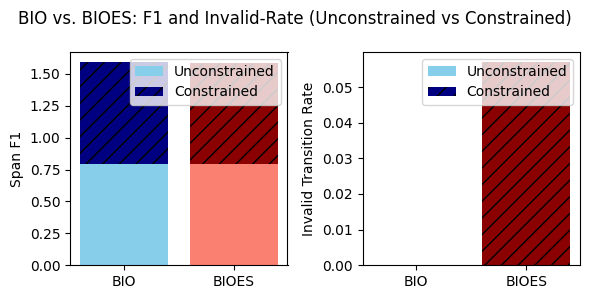

In [22]:
import matplotlib.pyplot as plt

# Prepare data for plotting
schemes = ['BIO','BIOES']
f1_scores = [f1_bio, f1_bioes]
inv_rates = [inv_bio, inv_bioes]
constr_f1 = [f1_bio_c, f1_bioes_c]
constr_inv = [inv_rate_bio_c, inv_rate_bioes_c]

x = range(len(schemes))
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plt.bar(x, f1_scores, color=['skyblue','salmon'], label='Unconstrained')
plt.bar(x, constr_f1, bottom=f1_scores, color=['navy','darkred'], hatch='//', label='Constrained')
plt.xticks(x, schemes)
plt.ylabel("Span F1")
plt.legend()

plt.subplot(1,2,2)
plt.bar(x, inv_rates, color=['skyblue','salmon'], label='Unconstrained')
plt.bar(x, constr_inv, bottom=inv_rates, color=['navy','darkred'], hatch='//', label='Constrained')
plt.xticks(x, schemes)
plt.ylabel("Invalid Transition Rate")
plt.legend()

plt.suptitle("BIO vs. BIOES: F1 and Invalid-Rate (Unconstrained vs Constrained)")
plt.tight_layout()
plt.show()